In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ts1 = pd.read_csv("ts_HDI1.csv")
ts2 = pd.read_csv("ts_HDI2.csv")
ts3 = pd.read_csv("ts_HDI3.csv")

In [4]:
ts = ts1.merge(ts2, on="Year")
ts = ts.merge(ts3, on="Year")

ts.head(5)

,Year,GDP per Capita (Constant 2015 US$),HDI_1,NIHDI1,HDI_2,NIHDI2,HDI3,NIHDI3
0,1990,537.9,0.272834,0.376667,0.190317,0.325235,0.162061,0.129411
1,1991,531.9,0.274671,0.380000,0.191410,0.330992,0.163819,0.131964
2,1992,549.2,0.278005,0.383333,0.196892,0.336650,0.166955,0.134488
3,1993,563.4,0.286696,0.395000,0.203677,0.347211,0.172246,0.139888
4,1994,588.7,0.290544,0.398333,0.210514,0.352767,0.175778,0.142414


In [5]:
ts['log_GDPpc'] = np.log(
    ts['GDP per Capita (Constant 2015 US$)']
)

print(ts[
    ['Year', 'GDP per Capita (Constant 2015 US$)', 'log_GDPpc']
].head())

   Year  GDP per Capita (Constant 2015 US$)  log_GDPpc
0  1990                               537.9   6.287673
1  1991                               531.9   6.276456
2  1992                               549.2   6.308463
3  1993                               563.4   6.333990
4  1994                               588.7   6.377917


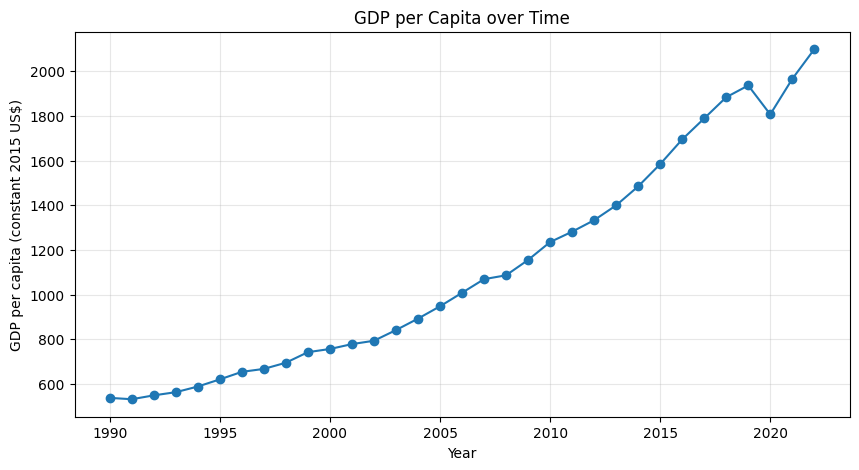

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    ts['Year'],
    ts['GDP per Capita (Constant 2015 US$)'],
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('GDP per capita (constant 2015 US$)')
plt.title('GDP per Capita over Time')
plt.grid(True, alpha=0.3)
plt.show()

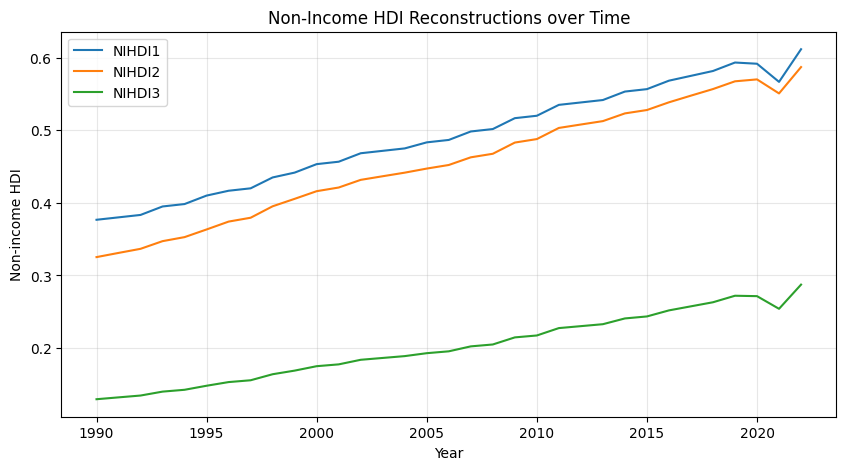

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(ts['Year'], ts['NIHDI1'], label='NIHDI1')
plt.plot(ts['Year'], ts['NIHDI2'], label='NIHDI2')
plt.plot(ts['Year'], ts['NIHDI3'], label='NIHDI3')

plt.xlabel('Year')
plt.ylabel('Non-income HDI')
plt.title('Non-Income HDI Reconstructions over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

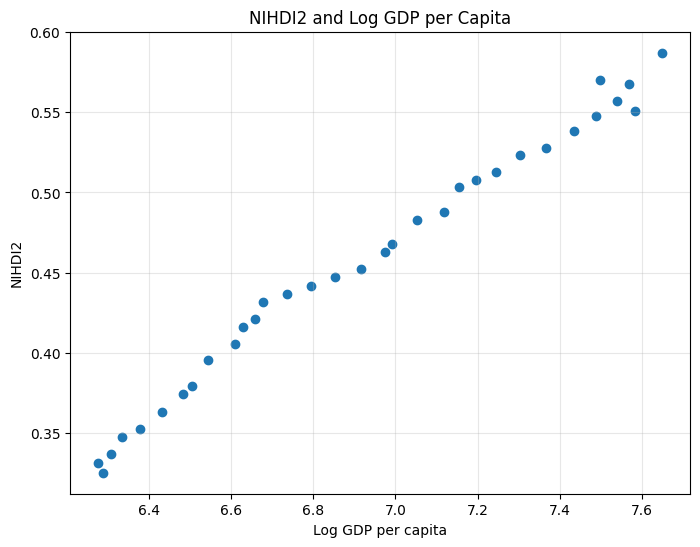

In [8]:
# SCATTERPLOTS
plt.figure(figsize=(8, 6))

plt.scatter(
    ts['log_GDPpc'],
    ts['NIHDI2']
)

plt.xlabel('Log GDP per capita')
plt.ylabel('NIHDI2')
plt.title('NIHDI2 and Log GDP per Capita')

plt.grid(True, alpha=0.3)
plt.show()

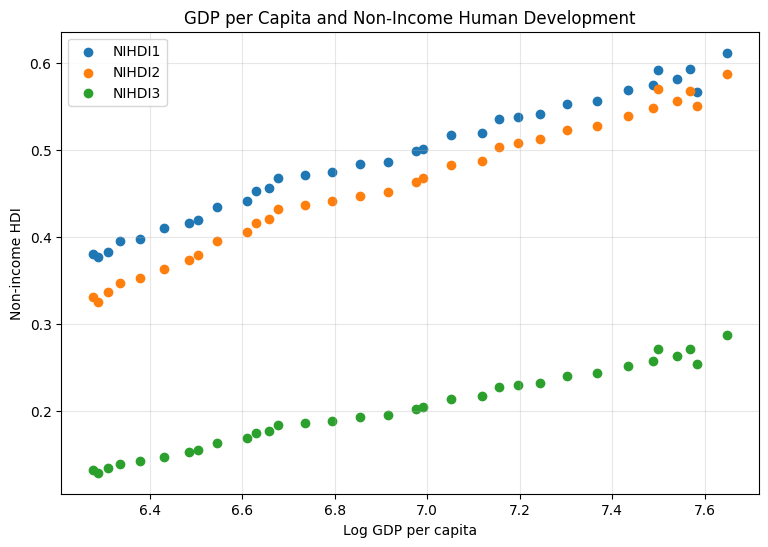

In [8]:
plt.figure(figsize=(9, 6))

plt.scatter(ts['log_GDPpc'], ts['NIHDI1'], label='NIHDI1')
plt.scatter(ts['log_GDPpc'], ts['NIHDI2'], label='NIHDI2')
plt.scatter(ts['log_GDPpc'], ts['NIHDI3'], label='NIHDI3')

plt.xlabel('Log GDP per capita')
plt.ylabel('Non-income HDI')
plt.title('GDP per Capita and Non-Income Human Development')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
corr = ts[
    [
        'log_GDPpc',
        'NIHDI1',
        'NIHDI2',
        'NIHDI3'
    ]
].corr()

print(corr)

           log_GDPpc    NIHDI1    NIHDI2    NIHDI3
log_GDPpc   1.000000  0.993066  0.993230  0.994313
NIHDI1      0.993066  1.000000  0.999375  0.998234
NIHDI2      0.993230  0.999375  1.000000  0.997549
NIHDI3      0.994313  0.998234  0.997549  1.000000


In [10]:
## OLS
import statsmodels.api as sm

X = sm.add_constant(ts['log_GDPpc'])
y = ts['NIHDI2']

model_NIHDI2 = sm.OLS(y, X).fit()

print(model_NIHDI2.summary())

                            OLS Regression Results                            
Dep. Variable:                 NIHDI2   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     2266.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.49e-30
Time:                        11:24:38   Log-Likelihood:                 108.66
No. Observations:                  33   AIC:                            -213.3
Df Residuals:                      31   BIC:                            -210.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7643      0.026    -29.756      0.0

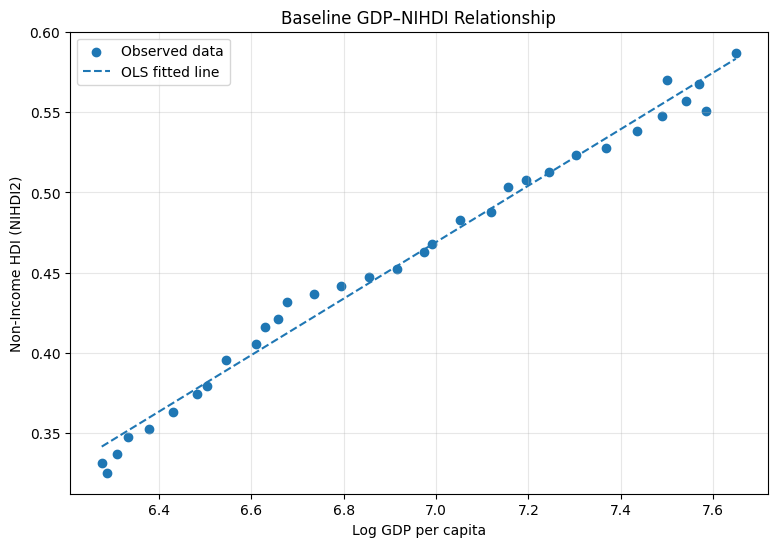

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Predicted values from the regression
y_pred = model_NIHDI2.predict(X)

plt.figure(figsize=(9,6))

# Actual observations
plt.scatter(
    ts['log_GDPpc'],
    ts['NIHDI2'],
    label='Observed data'
)

# Fitted regression line
order = np.argsort(ts['log_GDPpc'])

plt.plot(
    ts['log_GDPpc'].iloc[order],
    y_pred.iloc[order],
    linestyle='--',
    label='OLS fitted line'
)

plt.xlabel('Log GDP per capita')
plt.ylabel('Non-Income HDI (NIHDI2)')
plt.title('Baseline GDP–NIHDI Relationship')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [12]:
X = sm.add_constant(ts['log_GDPpc'])

model_NIHDI1 = sm.OLS(
    ts['NIHDI1'],
    X
).fit()

model_NIHDI2 = sm.OLS(
    ts['NIHDI2'],
    X
).fit()

model_NIHDI3 = sm.OLS(
    ts['NIHDI3'],
    X
).fit()

print("===== NIHDI1 =====")
print(model_NIHDI1.summary())

print("\n===== NIHDI2 =====")
print(model_NIHDI2.summary())

print("\n===== NIHDI3 =====")
print(model_NIHDI3.summary())

===== NIHDI1 =====
                            OLS Regression Results                            
Dep. Variable:                 NIHDI1   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     2212.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           2.16e-30
Time:                        02:37:52   Log-Likelihood:                 111.74
No. Observations:                  33   AIC:                            -219.5
Df Residuals:                      31   BIC:                            -216.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6071      0.023 

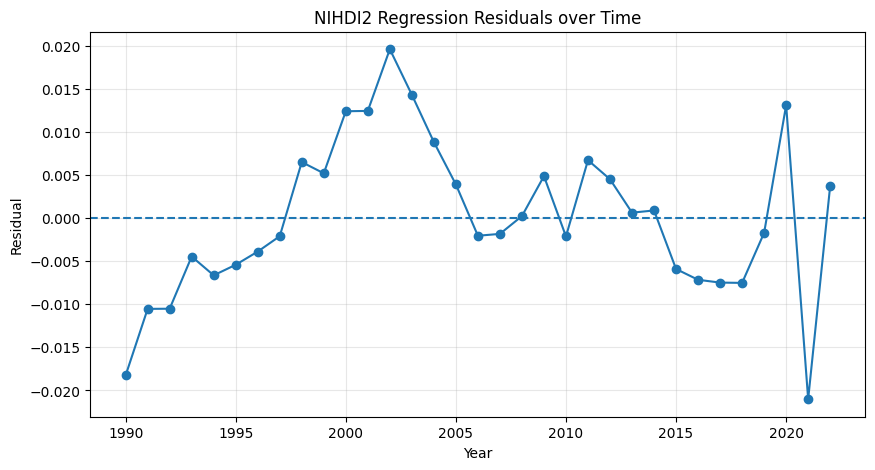

In [13]:
residuals = model_NIHDI2.resid
fitted = model_NIHDI2.fittedvalues

plt.figure(figsize=(10, 5))

plt.plot(
    ts['Year'],
    residuals,
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.xlabel('Year')
plt.ylabel('Residual')
plt.title('NIHDI2 Regression Residuals over Time')
plt.grid(True, alpha=0.3)
plt.show()

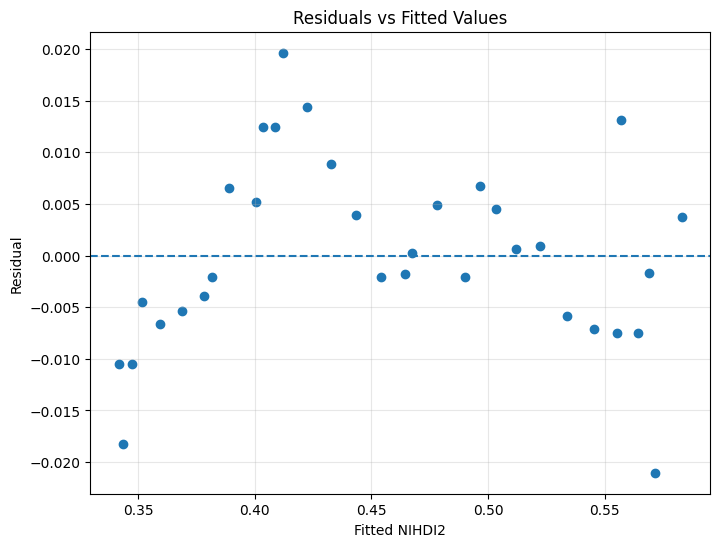

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(fitted, residuals)

plt.axhline(0, linestyle='--')

plt.xlabel('Fitted NIHDI2')
plt.ylabel('Residual')
plt.title('Residuals vs Fitted Values')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(model_NIHDI2.resid)

print("Durbin-Watson:", dw)

Durbin-Watson: 0.9989166968046714


In [16]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_test = acorr_breusch_godfrey(
    model_NIHDI2,
    nlags=1
)

print("LM statistic:", bg_test[0])
print("LM p-value:", bg_test[1])
print("F statistic:", bg_test[2])
print("F p-value:", bg_test[3])

LM statistic: 6.289695611212797
LM p-value: 0.012144190574886528
F statistic: 7.064347361597081
F p-value: 0.012484210101082114


/tmp/ipykernel_3009/3904891392.py:3: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  bg_test = acorr_breusch_godfrey(


In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model_NIHDI2.resid,
    model_NIHDI2.model.exog
)

print("LM statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F statistic:", bp_test[2])
print("F p-value:", bp_test[3])

LM statistic: 0.2652174967788452
LM p-value: 0.606558110517777
F statistic: 0.25116227362546795
F p-value: 0.6197981577065155


In [18]:
from statsmodels.tsa.stattools import adfuller

adf_gdp = adfuller(
    ts['log_GDPpc'],
    autolag='AIC'
)

print("ADF statistic:", adf_gdp[0])
print("ADF p-value:", adf_gdp[1])

ADF statistic: 0.6512500466067067
ADF p-value: 0.9888130402395662


/tmp/ipykernel_3009/3585211544.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_gdp = adfuller(


In [20]:
adf_nihdi2 = adfuller(
    ts['NIHDI2'],
    autolag='AIC'
)

print("ADF statistic:", adf_nihdi2[0])
print("ADF p-value:", adf_nihdi2[1])

ADF statistic: -1.1381047241618751
ADF p-value: 0.699639535515935


/tmp/ipykernel_3009/2197620008.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_nihdi2 = adfuller(


In [21]:
for col in ['NIHDI1', 'NIHDI2', 'NIHDI3']:
    result = adfuller(
        ts[col],
        autolag='AIC'
    )

    print(f"{col}")
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print()

NIHDI1
ADF statistic: -1.350994376192309
p-value: 0.6055317452672779

NIHDI2
ADF statistic: -1.1381047241618751
p-value: 0.699639535515935

NIHDI3
ADF statistic: 1.0748902538716623
p-value: 0.9949965197023187



/tmp/ipykernel_3009/1635156546.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_3009/1635156546.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_3009/1635156546.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or a

In [22]:
from statsmodels.tsa.stattools import adfuller

variables = {
    'log_GDPpc': ts['log_GDPpc'],
    'NIHDI1': ts['NIHDI1'],
    'NIHDI2': ts['NIHDI2'],
    'NIHDI3': ts['NIHDI3']
}

for name, series in variables.items():

    result = adfuller(series, autolag='AIC')

    print("=" * 40)
    print(name)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print("Number of lags:", result[2])
    print("Number of observations:", result[3])

log_GDPpc
ADF statistic: 0.6512500466067067
p-value: 0.9888130402395662
Number of lags: 0
Number of observations: 32
NIHDI1
ADF statistic: -1.350994376192309
p-value: 0.6055317452672779
Number of lags: 2
Number of observations: 30
NIHDI2
ADF statistic: -1.1381047241618751
p-value: 0.699639535515935
Number of lags: 1
Number of observations: 31
NIHDI3
ADF statistic: 1.0748902538716623
p-value: 0.9949965197023187
Number of lags: 10
Number of observations: 22


/tmp/ipykernel_3009/1321178407.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag='AIC')
/tmp/ipykernel_3009/1321178407.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag='AIC')
/tmp/ipykernel_3009/1321178407.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the st

In [23]:
ts['d_log_GDPpc'] = ts['log_GDPpc'].diff()

ts['d_NIHDI1'] = ts['NIHDI1'].diff()
ts['d_NIHDI2'] = ts['NIHDI2'].diff()
ts['d_NIHDI3'] = ts['NIHDI3'].diff()

In [24]:
variables_diff = {
    'd_log_GDPpc': ts['d_log_GDPpc'].dropna(),
    'd_NIHDI1': ts['d_NIHDI1'].dropna(),
    'd_NIHDI2': ts['d_NIHDI2'].dropna(),
    'd_NIHDI3': ts['d_NIHDI3'].dropna()
}

for name, series in variables_diff.items():

    result = adfuller(series, autolag='AIC')

    print("=" * 40)
    print(name)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])

d_log_GDPpc
ADF statistic: -5.613444610365757
p-value: 1.1890533013319796e-06
d_NIHDI1
ADF statistic: -1.0981855858548726
p-value: 0.715794929893822
d_NIHDI2
ADF statistic: -8.086476101277382
p-value: 1.4154048498534456e-12
d_NIHDI3
ADF statistic: -1.6091041433739197
p-value: 0.479018754223613


/tmp/ipykernel_3009/3280677832.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag='AIC')
/tmp/ipykernel_3009/3280677832.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag='AIC')
/tmp/ipykernel_3009/3280677832.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the st

In [26]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name, regression='c', maxlag=4):
    result = adfuller(
        series.dropna(),
        regression=regression,
        maxlag=maxlag,
        autolag='AIC'
    )

    print("=" * 50)
    print(name)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print("Used lags:", result[2])
    print("Observations:", result[3])

In [27]:
adf_test(
    ts['log_GDPpc'],
    'log GDP per capita — level',
    regression='ct',
    maxlag=4
)

adf_test(
    ts['NIHDI2'],
    'NIHDI2 — level',
    regression='ct',
    maxlag=4
)

log GDP per capita — level
ADF statistic: -3.2936905749805905
p-value: 0.0672962231410902
Used lags: 0
Observations: 32
NIHDI2 — level
ADF statistic: -4.241671000019779
p-value: 0.003869685365001803
Used lags: 0
Observations: 32


/tmp/ipykernel_3009/140263036.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_3009/140263036.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(


In [29]:
ts['d_log_GDPpc'] = ts['log_GDPpc'].diff()
ts['d_NIHDI2'] = ts['NIHDI2'].diff()

In [31]:
from statsmodels.tsa.stattools import coint

cointegration_test = coint(
    ts['NIHDI2'],
    ts['log_GDPpc'],
    trend='c'
)

print("Cointegration test statistic:", cointegration_test[0])
print("p-value:", cointegration_test[1])
print("Critical values:", cointegration_test[2])

Cointegration test statistic: -2.1637576693579734
p-value: 0.4431239451521491
Critical values: [-4.27142809 -3.53373371 -3.17964375]


In [32]:
adf_test(
    ts['d_log_GDPpc'],
    'Δ log GDP per capita',
    regression='c',
    maxlag=4
)

adf_test(
    ts['d_NIHDI2'],
    'Δ NIHDI2',
    regression='c',
    maxlag=4
)

Δ log GDP per capita
ADF statistic: -5.613444610365757
p-value: 1.1890533013319796e-06
Used lags: 0
Observations: 31
Δ NIHDI2
ADF statistic: -8.086476101277382
p-value: 1.4154048498534456e-12
Used lags: 0
Observations: 31


/tmp/ipykernel_3009/140263036.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_3009/140263036.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(


In [28]:
adf_test(
    ts['log_GDPpc'],
    'log GDP per capita — level',
    regression='ct',
    maxlag=4
)

adf_test(
    ts['NIHDI2'],
    'NIHDI2 — level',
    regression='ct',
    maxlag=4
)

adf_test(
    ts['d_log_GDPpc'],
    'Δ log GDP per capita',
    regression='c',
    maxlag=4
)

adf_test(
    ts['d_NIHDI2'],
    'Δ NIHDI2',
    regression='c',
    maxlag=4
)

log GDP per capita — level
ADF statistic: -3.2936905749805905
p-value: 0.0672962231410902
Used lags: 0
Observations: 32
NIHDI2 — level
ADF statistic: -4.241671000019779
p-value: 0.003869685365001803
Used lags: 0
Observations: 32
Δ log GDP per capita
ADF statistic: -5.613444610365757
p-value: 1.1890533013319796e-06
Used lags: 0
Observations: 31
Δ NIHDI2
ADF statistic: -8.086476101277382
p-value: 1.4154048498534456e-12
Used lags: 0
Observations: 31


/tmp/ipykernel_3009/140263036.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_3009/140263036.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(
/tmp/ipykernel_3009/140263036.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or afte

In [33]:
ts['trend'] = ts['Year'] - ts['Year'].min()

print(ts[['Year', 'trend']].head())

   Year  trend
0  1990      0
1  1991      1
2  1992      2
3  1993      3
4  1994      4


In [34]:
# CORREL(GDP,time)
print(
    ts[['log_GDPpc', 'trend']].corr()
)

           log_GDPpc     trend
log_GDPpc   1.000000  0.996537
trend       0.996537  1.000000


In [36]:
# TREND CONTROLLED MODEL
import statsmodels.api as sm

X = ts[['log_GDPpc', 'trend']]
X = sm.add_constant(X)

y = ts['NIHDI2']

model_trend = sm.OLS(y, X).fit()

print(model_trend.summary())

                            OLS Regression Results                            
Dep. Variable:                 NIHDI2   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     2329.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           1.24e-33
Time:                        03:15:50   Log-Likelihood:                 120.97
No. Observations:                  33   AIC:                            -235.9
Df Residuals:                      30   BIC:                            -231.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3443      0.193      1.783      0.0

In [38]:
# VIF TEST
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = ts[['log_GDPpc', 'trend']].copy()
X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame()

vif_table['Variable'] = X_vif.columns

vif_table['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_table)

    Variable         VIF
0      const    1.000000
1  log_GDPpc  144.644878
2      trend  144.644878


In [39]:
from statsmodels.stats.stattools import durbin_watson

dw_trend = durbin_watson(model_trend.resid)

print("Durbin-Watson:", dw_trend)

Durbin-Watson: 1.5312613787892098


In [40]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_trend = acorr_breusch_godfrey(
    model_trend,
    nlags=1
)

print("LM statistic:", bg_trend[0])
print("LM p-value:", bg_trend[1])
print("F statistic:", bg_trend[2])
print("F p-value:", bg_trend[3])

LM statistic: 1.8550939001030107
LM p-value: 0.17319210404477672
F statistic: 1.7273361791630397
F p-value: 0.19905240573430713


/tmp/ipykernel_3009/1671260123.py:3: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  bg_trend = acorr_breusch_godfrey(


In [41]:
diff_data = ts[
    ['d_NIHDI2', 'd_log_GDPpc']
].dropna()

X_diff = sm.add_constant(
    diff_data['d_log_GDPpc']
)

y_diff = diff_data['d_NIHDI2']

model_diff = sm.OLS(
    y_diff,
    X_diff
).fit()

print(model_diff.summary())

                            OLS Regression Results                            
Dep. Variable:               d_NIHDI2   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.032
Method:                 Least Squares   F-statistic:                   0.03278
Date:                Fri, 02 Oct 2026   Prob (F-statistic):              0.858
Time:                        03:18:51   Log-Likelihood:                 110.03
No. Observations:                  32   AIC:                            -216.1
Df Residuals:                      30   BIC:                            -213.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0078      0.003      3.044      

In [42]:
# LAGS
ts = ts.sort_values('Year').reset_index(drop=True)
ts['GDP_growth_lag1'] = ts['d_log_GDPpc'].shift(1)
ts['GDP_growth_lag2'] = ts['d_log_GDPpc'].shift(2)
ts['GDP_growth_lag3'] = ts['d_log_GDPpc'].shift(3)

In [43]:
print(
    ts[
        [
            'Year',
            'd_log_GDPpc',
            'GDP_growth_lag1',
            'GDP_growth_lag2',
            'GDP_growth_lag3',
            'd_NIHDI2'
        ]
    ].head(10)
)

   Year  d_log_GDPpc  GDP_growth_lag1  GDP_growth_lag2  GDP_growth_lag3  \
0  1990          NaN              NaN              NaN              NaN   
1  1991    -0.011217              NaN              NaN              NaN   
2  1992     0.032007        -0.011217              NaN              NaN   
3  1993     0.025527         0.032007        -0.011217              NaN   
4  1994     0.043927         0.025527         0.032007        -0.011217   
5  1995     0.052931         0.043927         0.025527         0.032007   
6  1996     0.052871         0.052931         0.043927         0.025527   
7  1997     0.019970         0.052871         0.052931         0.043927   
8  1998     0.040654         0.019970         0.052871         0.052931   
9  1999     0.065679         0.040654         0.019970         0.052871   

   d_NIHDI2  
0       NaN  
1  0.005757  
2  0.005658  
3  0.010561  
4  0.005556  
5  0.010551  
6  0.010848  
7  0.005308  
8  0.015776  
9  0.010268  


In [44]:
data_lag1 = ts[
    [
        'Year',
        'd_NIHDI2',
        'GDP_growth_lag1'
    ]
].dropna().copy()

print(data_lag1.head())
print("Observations:", len(data_lag1))

   Year  d_NIHDI2  GDP_growth_lag1
2  1992  0.005658        -0.011217
3  1993  0.010561         0.032007
4  1994  0.005556         0.025527
5  1995  0.010551         0.043927
6  1996  0.010848         0.052931
Observations: 31


In [45]:
import statsmodels.api as sm

X_lag1 = sm.add_constant(
    data_lag1['GDP_growth_lag1']
)

y_lag1 = data_lag1['d_NIHDI2']

model_lag1 = sm.OLS(
    y_lag1,
    X_lag1
).fit()

print(model_lag1.summary())

                            OLS Regression Results                            
Dep. Variable:               d_NIHDI2   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.370
Method:                 Least Squares   F-statistic:                     18.60
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           0.000170
Time:                        04:11:12   Log-Likelihood:                 113.81
No. Observations:                  31   AIC:                            -223.6
Df Residuals:                      29   BIC:                            -220.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0010      0.002     

In [46]:
from statsmodels.stats.stattools import durbin_watson

print(
    "Durbin-Watson:",
    durbin_watson(model_lag1.resid)
)

Durbin-Watson: 1.9922506459903657


In [47]:
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

bg_lag1 = acorr_breusch_godfrey(
    model_lag1,
    nlags=1
)

print("LM statistic:", bg_lag1[0])
print("LM p-value:", bg_lag1[1])
print("F statistic:", bg_lag1[2])
print("F p-value:", bg_lag1[3])

LM statistic: 1.9506438510695503
LM p-value: 0.16251748653687204
F statistic: 1.8801803231001453
F p-value: 0.1812041574027854


/tmp/ipykernel_3009/3738656156.py:3: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  bg_lag1 = acorr_breusch_godfrey(


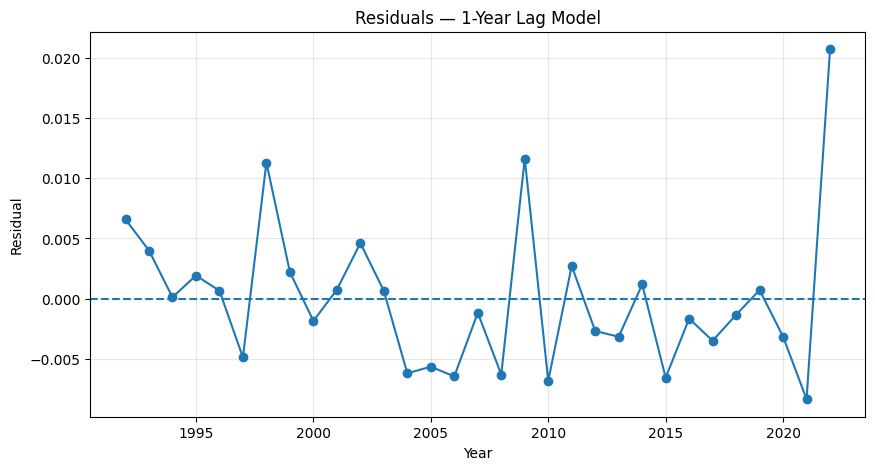

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    data_lag1['Year'],
    model_lag1.resid,
    marker='o'
)

plt.axhline(0, linestyle='--')

plt.xlabel('Year')
plt.ylabel('Residual')
plt.title('Residuals — 1-Year Lag Model')
plt.grid(True, alpha=0.3)

plt.show()

In [49]:
import statsmodels.api as sm

models_lag1 = {}

for nihdi in ['d_NIHDI1', 'd_NIHDI2', 'd_NIHDI3']:

    data = ts[
        [nihdi, 'GDP_growth_lag1']
    ].dropna()

    X = sm.add_constant(
        data['GDP_growth_lag1']
    )

    y = data[nihdi]

    model = sm.OLS(y, X).fit()

    models_lag1[nihdi] = model

    print("=" * 60)
    print(nihdi)
    print("Coefficient:",
          model.params['GDP_growth_lag1'])
    print("Std. Error:",
          model.bse['GDP_growth_lag1'])
    print("t-stat:",
          model.tvalues['GDP_growth_lag1'])
    print("p-value:",
          model.pvalues['GDP_growth_lag1'])
    print("R-squared:",
          model.rsquared)
    print("Durbin-Watson:",
          durbin_watson(model.resid))

d_NIHDI1
Coefficient: 0.218940676059758
Std. Error: 0.05059007140668834
t-stat: 4.3277400085031825
p-value: 0.0001632713986182025
R-squared: 0.3924071881149567
Durbin-Watson: 1.9758831253000175
d_NIHDI2
Coefficient: 0.17329987669516717
Std. Error: 0.04018009216345228
t-stat: 4.31307812809848
p-value: 0.0001699897556014717
R-squared: 0.3907901282474556
Durbin-Watson: 1.9922506459903657
d_NIHDI3
Coefficient: 0.1576531731175866
Std. Error: 0.034907201744169045
t-stat: 4.51635093162176
p-value: 9.704828524286344e-05
R-squared: 0.4129248727641891
Durbin-Watson: 1.8018083759032395


In [50]:
comparison_lag1 = pd.DataFrame({
    'NIHDI': ['NIHDI1', 'NIHDI2', 'NIHDI3'],

    'Coefficient': [
        models_lag1['d_NIHDI1'].params['GDP_growth_lag1'],
        models_lag1['d_NIHDI2'].params['GDP_growth_lag1'],
        models_lag1['d_NIHDI3'].params['GDP_growth_lag1']
    ],

    'p-value': [
        models_lag1['d_NIHDI1'].pvalues['GDP_growth_lag1'],
        models_lag1['d_NIHDI2'].pvalues['GDP_growth_lag1'],
        models_lag1['d_NIHDI3'].pvalues['GDP_growth_lag1']
    ],

    'R-squared': [
        models_lag1['d_NIHDI1'].rsquared,
        models_lag1['d_NIHDI2'].rsquared,
        models_lag1['d_NIHDI3'].rsquared
    ],

    'DW': [
        durbin_watson(models_lag1['d_NIHDI1'].resid),
        durbin_watson(models_lag1['d_NIHDI2'].resid),
        durbin_watson(models_lag1['d_NIHDI3'].resid)
    ]
})

print(comparison_lag1)

    NIHDI  Coefficient   p-value  R-squared        DW
0  NIHDI1     0.218941  0.000163   0.392407  1.975883
1  NIHDI2     0.173300  0.000170   0.390790  1.992251
2  NIHDI3     0.157653  0.000097   0.412925  1.801808
